In [1]:
import pandas as pd

In [3]:
df = pd.read_excel("Government_Securities_in_Excel.xlsx", index_col=0)

In [3]:
df.head()

,securityType,tenor,auctionNo,auction,week,maturityDate,totalSubscription,totalSuccessful,rangeBid,successfulBidRates,rateDescription,rate,trueYield,amtOffered,totalAmtRepaid,netType,netValue
auctionDate,,,,,,,,,,,,,,,,,
04/03/2026,NTB,91DAY,04-03-2026 91DAY,Primary Market,1st Week,04/06/2026,80923.856,64269.8540,14.8000 - 18.0000,14.800 - 15.9500,Issue,15.95,0.0000,100000.0000,0.0000,Sales,64269.8540
04/03/2026,NTB,182DAY,04-03-2026 182DAY,Primary Market,1st Week,03/09/2026,136539.824,91434.5230,15.0000 -18.8000,15.0000 - 16.6500,Issue,16.65,0.0000,150000.0000,0.0000,Sales,91434.5230
04/03/2026,NTB,364DAY,04-03-2026 364DAY,Primary Market,1st Week,04/03/2027,2126819.307,856034.5120,15.0000 - 22.0000,15.0000 - 16.7300,Issue,16.73,0.0000,80000.0000,0.0000,Sales,856034.5120
03/03/2026,OMO,7DAY,03-03-2026 7DAY,OMO,1st Week,10/03/2026,56000.000,0.0000,22.5000 - 23.0000,0.0000,Issue,0.00,0.0000,200000.0000,0.0000,Sales,0.0000
03/03/2026,OMO,98DAY,03-03-2026 98DAY,OMO,1st Week,09/06/2026,104250.000,62000.0000,19.3400 - 20.7700,19.3400 - 19.3500,Issue,19.35,0.0000,200000.0000,0.0000,Sales,62000.0000


In [4]:
df["tenor"].unique()

array(['91DAY', '182DAY', '364DAY', '7DAY', '98DAY', '105DAY', '207DAY',
       '354DAY', '208DAY', '348DAY', '203DAY', '161DAY', '210DAY',
       '168DAY', '162DAY', '211DAY', '180DAY', '215DAY', '174DAY',
       '188DAY', '175DAY', '152DAY', '173DAY', '56DAY', '81DAY', '91 DAY',
       '196DAY', '252DAY', '193DAY', '249DAY', '109DAY', '151DAY',
       '85DAY', '99DAY', '120DAY', '88DAY', '102DAY', '123DAY', '84DAY',
       '245DAY', '204DAY', '363DAY', '260DAY', '155DAY', '106DAY',
       '232DAY', '104DAY', '139DAY', '169DAY', '315DAY', '329DAY',
       '350DAY', '298DAY', '319DAY', '355DAY', '362DAY', '183 DAY',
       '347DAY', '361DAY', '358DAY', '365DAY', '90 DAY', '181 DAY',
       '363 DAY', '182 DAY', '364 DAY', '351DAY', '186DAY', '95DAY',
       '179DAY', '89 DAY', '187 DAY', '362 DAY', '193 DAY', '361 DAY',
       '96 DAY', '194 DAY', '365 DAY', '85 DAYS', '92DAY', '176DAY',
       '81 Day', '179 Day', '347 Day', '109 DAY', '186 DAY', '354 DAY',
       '188 DAY', '105 DAYS

In [5]:
df['securityType'].unique()

array(['NTB', 'OMO', 'OMOM', 'FGN BOND', 'FGN BONDS', 'FGN Bonds',
       'FGB BONDS', 'FGN BODS', 'OMO ', 'omo', 'FGN Bond', 'NT Bonds',
       'Others', 'Bonds', 'Nigerian Saving Certificate',
       'CBN Certificate'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4634 entries, 04/03/2026 to 26/02/2001
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   securityType        4634 non-null   object 
 1   tenor               4634 non-null   object 
 2   auctionNo           4634 non-null   object 
 3   auction             4634 non-null   object 
 4   week                4634 non-null   object 
 5   maturityDate        4634 non-null   object 
 6   totalSubscription   4634 non-null   float64
 7   totalSuccessful     4634 non-null   object 
 8   rangeBid            4634 non-null   object 
 9   successfulBidRates  4634 non-null   object 
 10  rateDescription     4634 non-null   object 
 11  rate                4634 non-null   float64
 12  trueYield           4634 non-null   object 
 13  amtOffered          4634 non-null   object 
 14  totalAmtRepaid      4634 non-null   object 
 15  netType             4634 non-null   object 
 

In [7]:
df.isnull().sum()

,0
securityType,0
tenor,0
auctionNo,0
auction,0
week,0
maturityDate,0
totalSubscription,0
totalSuccessful,0
rangeBid,0
successfulBidRates,0


In [5]:
import pandas as pd
import numpy as np
import re

def clean_tenor(tenor):
    """
    Convert messy tenor strings to a standardised number of days.
    Returns None if the tenor cannot be parsed.
    """
    if pd.isna(tenor):
        return None

    # Clean up whitespace and convert to uppercase
    t = str(tenor).strip().upper()

    # ── YEAR-BASED TENORS ─────────────────────────────────────────────
    year_patterns = [
        r'(\d+)\s*-?\s*YEAR',   # 10YEAR, 10-YEAR, 10 YEAR, 10 YEARS
        r'(\d+)\s*YR',          # 10YR
    ]
    for pattern in year_patterns:
        match = re.search(pattern, t)
        if match:
            return int(match.group(1)) * 365  # convert years to days

    # ── DAY-BASED TENORS ──────────────────────────────────────────────
    day_patterns = [
        r'(\d+)\s*-?\s*DAY',    # 91DAY, 91-DAY, 91 DAY, 91 DAYS
        r'(\d+)\s*D$',          # 91D
    ]
    for pattern in day_patterns:
        match = re.search(pattern, t)
        if match:
            return int(match.group(1))

    # ── PURE NUMBERS ──────────────────────────────────────────────────
    # If it's just a number, treat as days if <= 366, years*365 if > 366
    try:
        val = float(t)
        if val <= 366:
            return int(val)       # treat as days
        else:
            return None           # ambiguous large numbers — discard
    except ValueError:
        return None


# ── APPLY TO YOUR DATAFRAME ───────────────────────────────────────────
# Assuming your dataframe is called df and the column is 'Tenor'
df['tenor_days'] = df['tenor'].apply(clean_tenor)

# ── MAP TO STANDARD MATURITIES ────────────────────────────────────────
# Define the buckets we care about (in days)
# with a tolerance window around each
maturity_buckets = {
    91:    '3M',
    182:   '6M',
    364:   '1Y',
    2 * 365:  '2Y',
    3 * 365:  '3Y',
    5 * 365:  '5Y',
    7 * 365:  '7Y',
    10 * 365: '10Y',
    15 * 365: '15Y',
    20 * 365: '20Y',
    25 * 365: '25Y',
    30 * 365: '30Y',
}

def assign_bucket(days, tolerance=15):
    """
    Assign a tenor_days value to the nearest standard maturity bucket.
    Returns None if no bucket is within tolerance.
    """
    if pd.isna(days):
        return None
    for bucket_days, label in maturity_buckets.items():
        if abs(days - bucket_days) <= tolerance:
            return label
    return None  # doesn't fit any standard bucket

df['maturity'] = df['tenor_days'].apply(assign_bucket)

# ── QUICK AUDIT ───────────────────────────────────────────────────────
print("=== Cleaning Summary ===")
print(f"Total rows:            {len(df)}")
print(f"Successfully parsed:   {df['tenor_days'].notna().sum()}")
print(f"Mapped to bucket:      {df['maturity'].notna().sum()}")
print(f"Lost to noise:         {df['maturity'].isna().sum()}")
print()
print("=== Rows per maturity bucket ===")
print(df['maturity'].value_counts().sort_index())
print()
print("=== Unmapped tenors (sample) ===")
unmapped = df[df['maturity'].isna()]['tenor'].unique()
print(unmapped[:20])

=== Cleaning Summary ===
Total rows:            4634
Successfully parsed:   4613
Mapped to bucket:      3244
Lost to noise:         1390

=== Rows per maturity bucket ===
maturity
10Y     107
15Y      17
1Y      710
20Y      57
25Y      10
30Y      29
3M     1113
3Y       16
5Y       70
6M     1098
7Y       17
Name: count, dtype: int64

=== Unmapped tenors (sample) ===
['7DAY' '207DAY' '208DAY' '348DAY' '203DAY' '161DAY' '210DAY' '162DAY'
 '211DAY' '215DAY' '152DAY' '56DAY' '252DAY' '249DAY' '109DAY' '151DAY'
 '120DAY' '123DAY' '245DAY' '204DAY']


In [6]:
# ── EXPANDED MATURITY BUCKETS WITH WIDER TOLERANCE ───────────────────
def assign_bucket_v2(days):
    """
    More generous bucketing that captures off-cycle auction tenors.
    """
    if pd.isna(days):
        return None

    # Short-term NTB buckets (tight tolerance — these are precise)
    if 84 <= days <= 98:      return '3M'
    if 168 <= days <= 196:    return '6M'
    if 340 <= days <= 370:    return '1Y'

    # Medium-term buckets (wider tolerance)
    if 100 <= days <= 167:    return 'SHORT'   # catch 109, 120, 123 etc
    if 197 <= days <= 280:    return 'MED'     # catch 207, 210, 245 etc
    if 281 <= days <= 339:    return 'LONG_ST' # catch 315, 329 etc

    # Long-term FGN Bond buckets (years — very wide tolerance)
    if 600 <= days <= 850:      return '2Y'
    if 900 <= days <= 1200:     return '3Y'
    if 1600 <= days <= 2000:    return '5Y'
    if 2300 <= days <= 2700:    return '7Y'
    if 3400 <= days <= 3900:    return '10Y'
    if 5000 <= days <= 5800:    return '15Y'
    if 6900 <= days <= 7600:    return '20Y'
    if 8800 <= days <= 9500:    return '25Y'
    if 10500 <= days <= 11000:  return '30Y'

    return None

# Apply updated bucketing
df['maturity_v2'] = df['tenor_days'].apply(assign_bucket_v2)

# ── NEW AUDIT ─────────────────────────────────────────────────────────
print("=== Updated Cleaning Summary ===")
print(f"Total rows:          {len(df)}")
print(f"Mapped to bucket:    {df['maturity_v2'].notna().sum()}")
print(f"Still unmapped:      {df['maturity_v2'].isna().sum()}")
print()
print("=== Rows per maturity bucket ===")
print(df['maturity_v2'].value_counts().sort_index())
print()

# Check what's still unmapped
still_lost = df[df['maturity_v2'].isna()]['tenor_days'].dropna()
print("=== Still unmapped tenor_days (sample) ===")
print(sorted(still_lost.unique())[:30])

=== Updated Cleaning Summary ===
Total rows:          4634
Mapped to bucket:    3862
Still unmapped:      772

=== Rows per maturity bucket ===
maturity_v2
10Y         107
15Y          17
1Y          769
20Y          57
25Y          10
30Y          29
3M         1006
3Y           16
5Y           70
6M         1083
7Y           17
LONG_ST     121
MED         201
SHORT       359
Name: count, dtype: int64

=== Still unmapped tenor_days (sample) ===
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(10.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(41.0)]


In [7]:
# Use only the three well-populated maturities for now
core_maturities = ['3M', '6M', '1Y', '10Y']

df_core = df[df['maturity_v2'].isin(core_maturities)].copy()

# Reset the index to make 'auctionDate' a regular column
df_core = df_core.reset_index()

# Convert auction date to datetime, specifying dayfirst=True
df_core['auctionDate'] = pd.to_datetime(df_core['auctionDate'], dayfirst=True)

# Pivot to yield curve format
yield_curve = df_core.pivot_table(
    index='auctionDate',
    columns='maturity_v2',
    values='rate', # Corrected from 'Rate' to 'rate'
    aggfunc='mean'
)

# Reorder columns
yield_curve = yield_curve[['3M', '6M', '1Y', '10Y']]

print("=== Yield Curve Dataset ===")
print(f"Date range: {yield_curve.index.min()} to {yield_curve.index.max()}")
print(f"Shape: {yield_curve.shape}")
print(f"\nMissing values:\n{yield_curve.isnull().sum()}")
print(f"\nFirst 5 rows:\n{yield_curve.head()}")
print(f"\nBasic statistics:\n{yield_curve.describe()}")

=== Yield Curve Dataset ===
Date range: 2001-02-26 00:00:00 to 2026-03-04 00:00:00
Shape: (1546, 4)

Missing values:
maturity_v2
3M      555
6M      479
1Y      793
10Y    1450
dtype: int64

First 5 rows:
maturity_v2  3M    6M    1Y  10Y
auctionDate                     
2001-02-26  NaN  19.0   NaN  NaN
2001-03-12  NaN  19.0   NaN  NaN
2001-03-26  NaN  19.0   NaN  NaN
2001-04-17  NaN   NaN  21.5  NaN
2001-05-28  NaN  19.0   NaN  NaN

Basic statistics:
maturity_v2          3M           6M          1Y        10Y
count        991.000000  1067.000000  753.000000  96.000000
mean           9.410519    10.954487   12.797578  13.235219
std            5.267707     5.054223    5.037140   2.209169
min            0.000000     0.000000    0.000000   6.000000
25%            5.500000     7.580000    9.599900  12.000000
50%            9.980000    10.850000   12.850000  13.500000
75%           13.250000    14.840000   16.899000  14.585000
max           26.440000    24.500000   24.360000  16.994500


In [8]:
yield_curve.tail()

maturity_v2,3M,6M,1Y,10Y
auctionDate,,,,
2026-01-29,NaN,NaN,17.250,NaN
2026-01-30,NaN,NaN,17.250,NaN
2026-02-04,15.84,16.65,16.987,NaN
2026-03-03,19.35,NaN,NaN,NaN
2026-03-04,15.95,16.65,16.730,NaN


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── STEP 1: REMOVE ZERO AND SUSPICIOUS YIELDS ─────────────────────────
print("=== Before cleaning ===")
print(yield_curve.describe())

# Remove zeros and near-zeros (likely data errors)
yield_curve_clean = yield_curve.copy()
yield_curve_clean[yield_curve_clean < 1.0] = np.nan

print("\n=== After removing zeros ===")
print(yield_curve_clean.describe())

# ── STEP 2: FILL GAPS USING FORWARD FILL (max 7 days) ─────────────────
# Since auctions don't happen every day, fill short gaps only
yield_curve_filled = yield_curve_clean.copy()
yield_curve_filled = yield_curve_filled.ffill(limit=7)

# ── STEP 3: SPLIT INTO MEANINGFUL PERIODS ─────────────────────────────
# Based on CBN MPR history
periods = {
    'Pre-Crisis (2001–2008)':      ('2001-01-01', '2008-12-31'),
    'Post-Crisis (2009–2015)':     ('2009-01-01', '2015-12-31'),
    'Recession Period (2016–2017)':('2016-01-01', '2017-12-31'),
    'Stability (2018–2021)':       ('2018-01-01', '2021-12-31'),
    'Hiking Cycle (2022–2024)':    ('2022-01-01', '2024-12-31'),
}

print("\n=== Data availability per period ===")
for period_name, (start, end) in periods.items():
    subset = yield_curve_clean.loc[start:end]
    print(f"\n{period_name}")
    print(f"  Rows: {len(subset)}")
    print(f"  3M available:  {subset['3M'].notna().sum()}")
    print(f"  6M available:  {subset['6M'].notna().sum()}")
    print(f"  1Y available:  {subset['1Y'].notna().sum()}")
    print(f"  10Y available: {subset['10Y'].notna().sum()}")

# ── STEP 4: CALCULATE SLOPE (our key metric) ──────────────────────────
# Use 1Y minus 3M as our primary slope measure
# (since 10Y data is too sparse for continuous slope)
yield_curve_clean['slope_1Y_3M'] = (
    yield_curve_clean['1Y'] - yield_curve_clean['3M']
)

# Where we have 10Y, also calculate the longer slope
yield_curve_clean['slope_10Y_3M'] = (
    yield_curve_clean['10Y'] - yield_curve_clean['3M']
)

print("\n=== Slope Statistics ===")
print(yield_curve_clean[['slope_1Y_3M', 'slope_10Y_3M']].describe())

# ── STEP 5: RESAMPLE TO MONTHLY (cleaner for visualisation) ───────────
yield_monthly = yield_curve_clean.resample('ME').mean()

print("\n=== Monthly dataset ===")
print(f"Shape: {yield_monthly.shape}")
print(f"Date range: {yield_monthly.index.min()} to {yield_monthly.index.max()}")
print(yield_monthly.head(10))

=== Before cleaning ===
maturity_v2          3M           6M          1Y        10Y
count        991.000000  1067.000000  753.000000  96.000000
mean           9.410519    10.954487   12.797578  13.235219
std            5.267707     5.054223    5.037140   2.209169
min            0.000000     0.000000    0.000000   6.000000
25%            5.500000     7.580000    9.599900  12.000000
50%            9.980000    10.850000   12.850000  13.500000
75%           13.250000    14.840000   16.899000  14.585000
max           26.440000    24.500000   24.360000  16.994500

=== After removing zeros ===
maturity_v2          3M           6M          1Y        10Y
count        938.000000  1038.000000  744.000000  96.000000
mean           9.940196    11.258572   12.950466  13.235219
std            4.905717     4.780523    4.870388   2.209169
min            1.000000     1.000000    1.139000   6.000000
25%            6.325000     7.790000    9.750000  12.000000
50%           10.000000    11.000000   12.9200

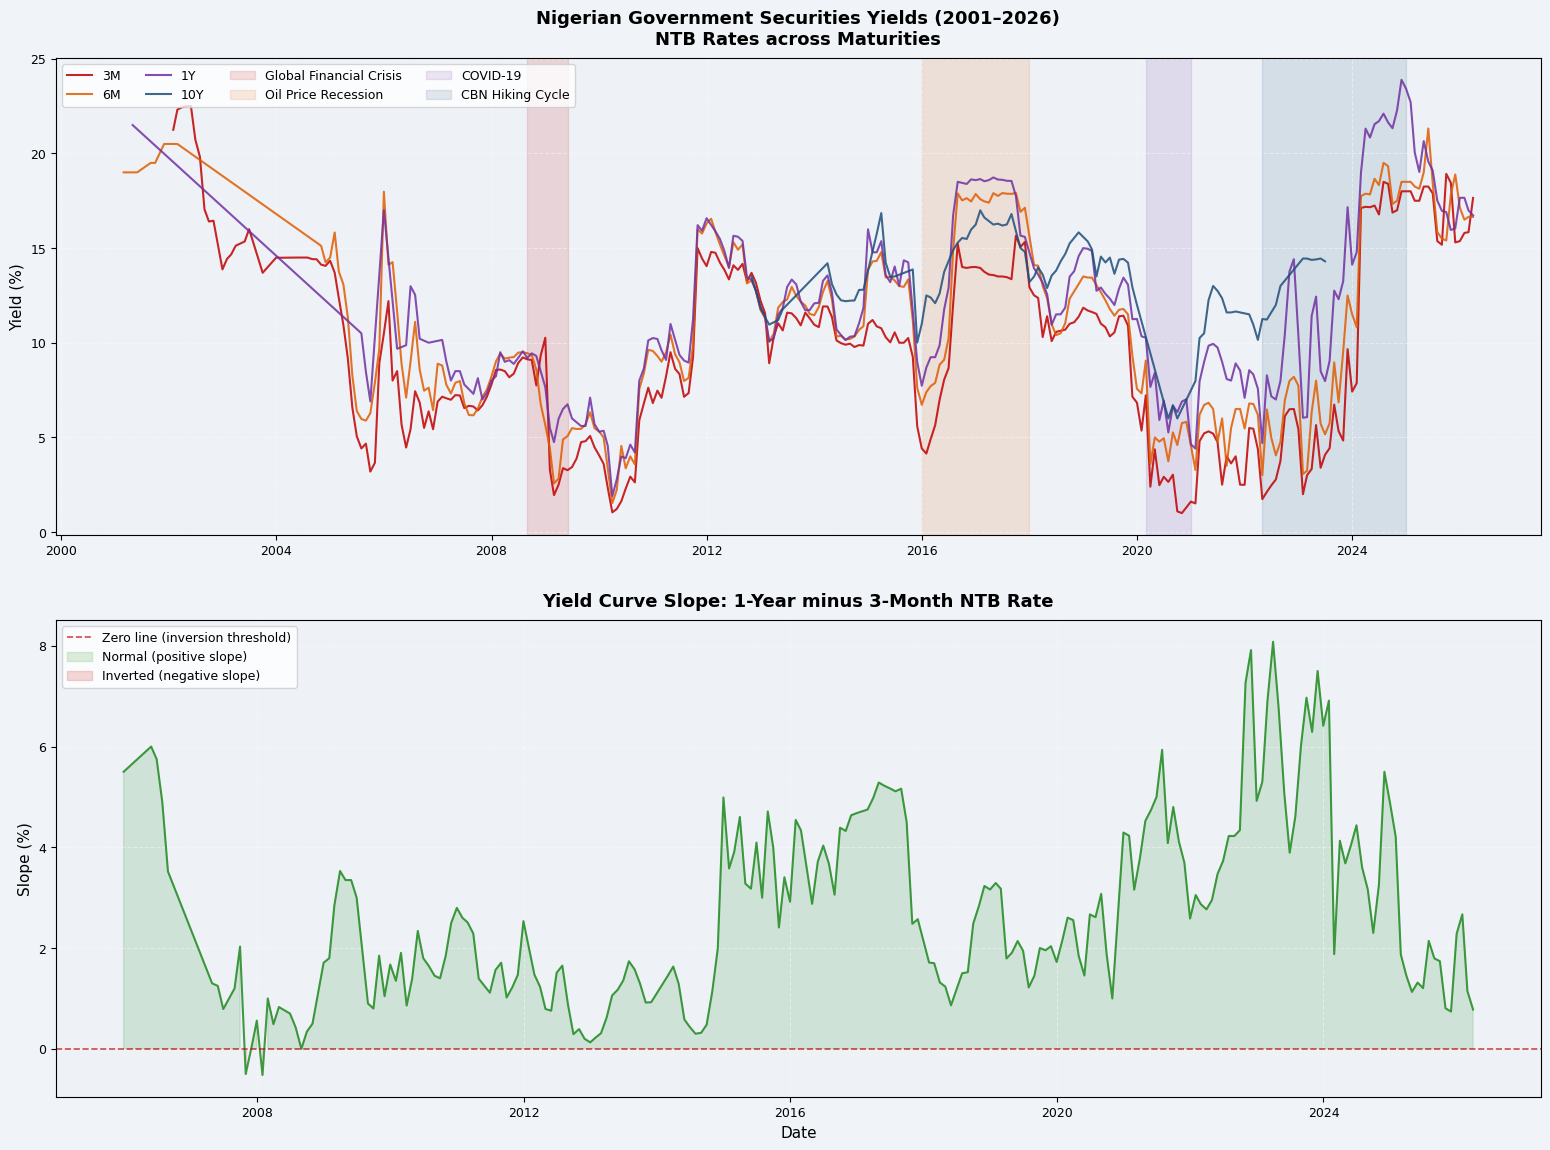

Chart saved.


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── FIGURE 1: Full time series (equivalent to CMT chart) ──────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#f0f4f8')

colors = {'3M': '#c00000', '6M': '#e05c00',
          '1Y': '#7030a0', '10Y': '#1f4e79'}

# Top panel — yield levels
ax1 = axes[0]
ax1.set_facecolor('#eef2f7')
ax1.grid(True, linestyle='--', alpha=0.4, color='white')

for col in ['3M', '6M', '1Y', '10Y']:
    data = yield_monthly[col].dropna()
    ax1.plot(data.index, data,
             color=colors[col], linewidth=1.5,
             label=col, alpha=0.85)

# Shade Nigerian recession/crisis periods
crisis_periods = [
    ('2008-09-01', '2009-06-01', '#c00000', 'Global Financial Crisis'),
    ('2016-01-01', '2017-12-31', '#e05c00', 'Oil Price Recession'),
    ('2020-03-01', '2020-12-31', '#7030a0', 'COVID-19'),
    ('2022-05-01', '2024-12-31', '#1f4e79', 'CBN Hiking Cycle'),
]

for start, end, color, label in crisis_periods:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                alpha=0.12, color=color, label=label)

ax1.set_title('Nigerian Government Securities Yields (2001–2026)\n'
              'NTB Rates across Maturities',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Yield (%)', fontsize=11)
ax1.legend(fontsize=9, ncol=4, loc='upper left')
ax1.tick_params(labelsize=9)

# Bottom panel — slope (1Y minus 3M)
ax2 = axes[1]
ax2.set_facecolor('#eef2f7')
ax2.grid(True, linestyle='--', alpha=0.4, color='white')

slope_data = yield_monthly['slope_1Y_3M'].dropna()
ax2.plot(slope_data.index, slope_data,
         color='#228B22', linewidth=1.5, alpha=0.85)
ax2.axhline(y=0, color='#c00000', linewidth=1.2,
            linestyle='--', alpha=0.7, label='Zero line (inversion threshold)')
ax2.fill_between(slope_data.index, slope_data, 0,
                 where=(slope_data >= 0),
                 alpha=0.15, color='#228B22', label='Normal (positive slope)')
ax2.fill_between(slope_data.index, slope_data, 0,
                 where=(slope_data < 0),
                 alpha=0.15, color='#c00000', label='Inverted (negative slope)')

ax2.set_title('Yield Curve Slope: 1-Year minus 3-Month NTB Rate',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel('Slope (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.tick_params(labelsize=9)

plt.tight_layout(pad=2.5)

# Create the directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'nigeria_yield_curve_full.png'),
            dpi=150, bbox_inches='tight', facecolor='#f0f4f8')
plt.show()
print("Chart saved.")

In [14]:
import pandas as pd
import requests

# Option 1 — World Bank API (has some Nigerian rate data)
# Interest rates and inflation indicators
# Fetch 'Lending interest rate (%)' (FR.INR.LEND) for Nigeria
url_lending_rate = "https://api.worldbank.org/v2/country/NG/indicator/FR.INR.LEND?format=json&date=2010:2024&per_page=500"
response_lending_rate = requests.get(url_lending_rate)
data_lending_rate = response_lending_rate.json()

# Extract and structure the data
# The first element of the JSON response is metadata, the second is the actual data
if data_lending_rate and len(data_lending_rate) > 1:
    lending_rates = []
    for record in data_lending_rate[1]:
        if record['value'] is not None:
            lending_rates.append({
                'country': record['country']['value'],
                'date': int(record['date']),
                'lending_rate': float(record['value'])
            })
    df_lending = pd.DataFrame(lending_rates)
    if not df_lending.empty:
        df_lending['date'] = pd.to_datetime(df_lending['date'], format='%Y')
        df_lending = df_lending.set_index('date').sort_index()
        print("World Bank Lending Rates (FR.INR.LEND):")
        print(df_lending.head())
    else:
        print("No lending rate data found in the World Bank API response.")
else:
    print("Invalid World Bank API response for lending rates.")

# Option 2 — IMF Data (sovereign bond yields for emerging markets)
# Navigate to: imf.org/en/Data → IMF Data API

# Option 3 — pandas_datareader (commented out as it's causing issues)
# import pandas_datareader as pdr
# # The correct function for World Bank data is pdr.wb.download
# # df = pdr.wb.download(indicator='FR.INR.LEND', country='NG', start=2010, end=2024)
# # print(df.head())

World Bank Lending Rates (FR.INR.LEND):
            country  lending_rate
date                             
2010-01-01  Nigeria     17.585000
2011-01-01  Nigeria     16.020000
2012-01-01  Nigeria     16.791667
2013-01-01  Nigeria     16.722500
2014-01-01  Nigeria     16.548333


In [15]:
df_lending.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14 entries, 2010-01-01 to 2023-01-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       14 non-null     object 
 1   lending_rate  14 non-null     float64
dtypes: float64(1), object(1)
memory usage: 336.0+ bytes
